<a href="https://colab.research.google.com/github/Aminata31/Projet-Analyse-Donnees-Education/blob/main/Analyse_scolaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# 1. Chargement des données
df_mat = pd.read_csv("student-mat.csv")
df_por = pd.read_csv("student-por.csv")

# 2. Ajout de la colonne pour identifier la matière
df_mat['subject'] = 'Maths'
df_por['subject'] = 'Portugais'

# 3. Liste STRICTE des attributs sociaux et démographiques immuables
identifiants_sociaux = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures", "schoolsup", "famsup",
    "activities", "nursery", "higher", "internet", "romantic",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

# 4. Fusion (on exclut 'absences' et 'paid' de la jointure pour ne pas perdre d'élèves)
df_final = pd.merge(df_mat, df_por, on=identifiants_sociaux, suffixes=('_mat', '_por'))

# 5. Affichage des résultats
print(f"Nombre de lignes pour les Maths : {df_mat.shape[0]}")
print(f"Nombre de lignes pour le Portugais : {df_por.shape[0]}")
print("-" * 40)
print(f"Nombre de lignes après fusion correcte : {df_final.shape[0]}")

Nombre de lignes pour les Maths : 395
Nombre de lignes pour le Portugais : 649
----------------------------------------
Nombre de lignes après fusion correcte : 320


In [ ]:
print("--- 1. VÉRIFICATION DES VALEURS MANQUANTES ---")
print(df_final.isnull().sum().sum())  # Doit afficher 0 si le dataset est parfaitement propre

print("\n--- 2. APERÇU DES TYPES DE COLONNES ---")
# On regarde les premières colonnes et les nouvelles colonnes de notes
colonnes_interet = ['school', 'sex', 'age', 'G3_mat', 'G3_por']
print(df_final[colonnes_interet].dtypes)

print("\n--- 3. STATISTIQUES DESCRIPTIVES DES NOTES FINALES ---")
print(df_final[['G3_mat', 'G3_por']].describe())

--- 1. VÉRIFICATION DES VALEURS MANQUANTES ---
0

--- 2. APERÇU DES TYPES DE COLONNES ---
school    object
sex       object
age        int64
G3_mat     int64
G3_por     int64
dtype: object

--- 3. STATISTIQUES DESCRIPTIVES DES NOTES FINALES ---
           G3_mat      G3_por
count  320.000000  320.000000
mean    11.040625   12.884375
std      4.302245    2.888048
min      0.000000    0.000000
25%      9.000000   11.000000
50%     11.000000   13.000000
75%     14.000000   15.000000
max     20.000000   19.000000


In [ ]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. CORRÉLATION : TEMPS D'ÉTUDE VS NOTES FINALES ---")
corr_etude_mat, p_mat = stats.pearsonr(df_final['studytime'], df_final['G3_mat'])
corr_etude_por, p_por = stats.pearsonr(df_final['studytime'], df_final['G3_por'])

print(f"Maths -> Corrélation: {corr_etude_mat:.3f} (p-value: {p_mat:.5f})")
print(f"Portugais -> Corrélation: {corr_etude_por:.3f} (p-value: {p_por:.5f})")

print("\n--- 2. CORRÉLATION : ALCOOL (WEEK-END) VS NOTES FINALES ---")
corr_alc_mat, p_alc_mat = stats.pearsonr(df_final['Walc'], df_final['G3_mat'])
corr_alc_por, p_alc_por = stats.pearsonr(df_final['Walc'], df_final['G3_por'])

print(f"Maths -> Corrélation: {corr_alc_mat:.3f} (p-value: {p_alc_mat:.5f})")
print(f"Portugais -> Corrélation: {corr_alc_por:.3f} (p-value: {p_alc_por:.5f})")

--- 1. CORRÉLATION : TEMPS D'ÉTUDE VS NOTES FINALES ---
Maths -> Corrélation: 0.045 (p-value: 0.41827)
Portugais -> Corrélation: 0.239 (p-value: 0.00002)

--- 2. CORRÉLATION : ALCOOL (WEEK-END) VS NOTES FINALES ---
Maths -> Corrélation: -0.028 (p-value: 0.62251)
Portugais -> Corrélation: -0.183 (p-value: 0.00103)


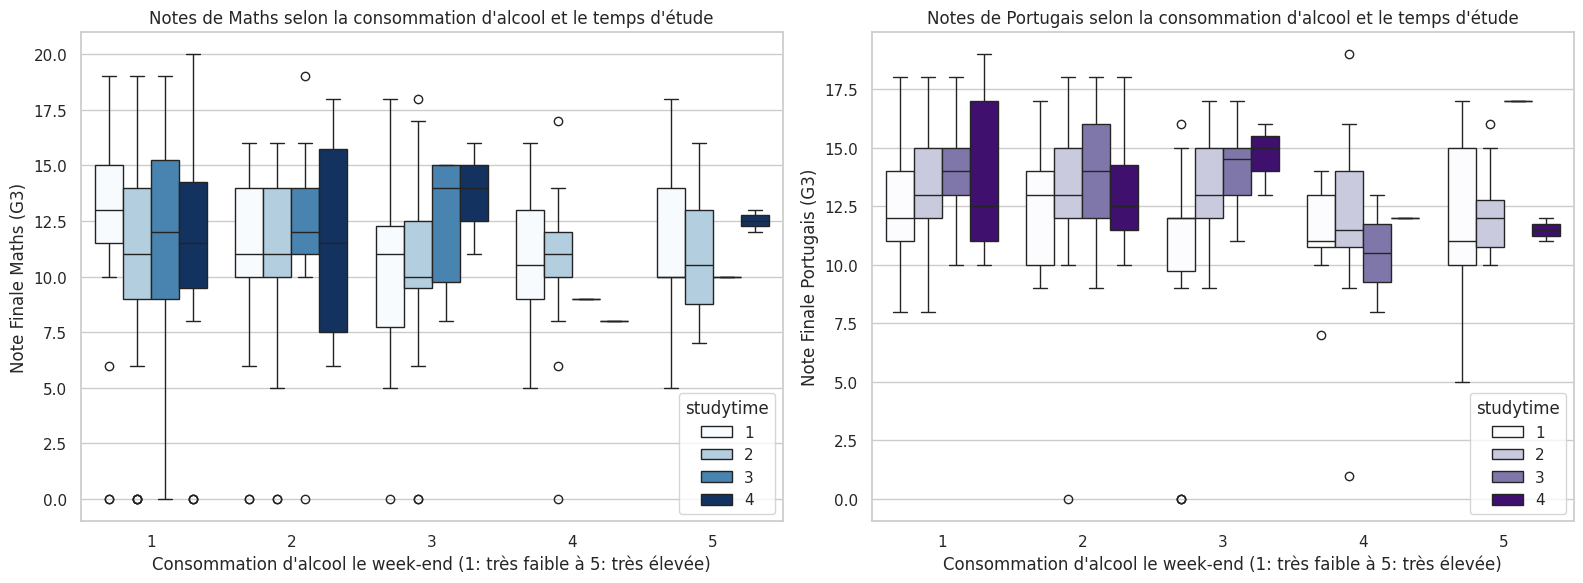

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Boxplot pour les Mathématiques
sns.boxplot(ax=axes[0], data=df_final, x="Walc", y="G3_mat", hue="studytime", palette="Blues")
axes[0].set_title("Notes de Maths selon la consommation d'alcool et le temps d'étude")
axes[0].set_xlabel("Consommation d'alcool le week-end (1: très faible à 5: très élevée)")
axes[0].set_ylabel("Note Finale Maths (G3)")

# Graphique 2 : Boxplot pour le Portugais
sns.boxplot(ax=axes[1], data=df_final, x="Walc", y="G3_por", hue="studytime", palette="Purples")
axes[1].set_title("Notes de Portugais selon la consommation d'alcool et le temps d'étude")
axes[1].set_xlabel("Consommation d'alcool le week-end (1: très faible à 5: très élevée)")
axes[1].set_ylabel("Note Finale Portugais (G3)")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

print("--- 1. TEST DE STUDENT (T-TEST) ---")
# On sépare les élèves en deux groupes : faible consommation d'alcool (1-2) vs forte consommation (3-5)
groupe_faible_alc = df_final[df_final['Walc'] <= 2]['G3_por']
groupe_forte_alc = df_final[df_final['Walc'] >= 3]['G3_por']

t_stat, t_p_value = stats.ttest_ind(groupe_faible_alc, groupe_forte_alc, equal_var=False)
print(f"Test de Student pour le Portugais : t = {t_stat:.3f}, p-value = {t_p_value:.5f}")


print("\n--- 2. SEGMENTATION / CLUSTERING (K-MEANS) ---")
# Sélection des variables numériques clés pour créer des profils d'élèves
features_clustering = ['age', 'studytime', 'failures', 'Dalc', 'Walc', 'G3_mat', 'G3_por']
X = df_final[features_clustering]

# Normalisation des données (étape obligatoire pour le K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Application du K-Means pour créer 3 profils/groupes d'élèves
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

# Affichage des caractéristiques moyennes de chaque groupe d'élèves créé
print("\nCaractéristiques moyennes de nos 3 profils d'élèves :")
display(df_final.groupby('Cluster')[features_clustering].mean())

--- 1. TEST DE STUDENT (T-TEST) ---
Test de Student pour le Portugais : t = 2.822, p-value = 0.00523

--- 2. SEGMENTATION / CLUSTERING (K-MEANS) ---

Caractéristiques moyennes de nos 3 profils d'élèves :


,age,studytime,failures,Dalc,Walc,G3_mat,G3_por
Cluster,,,,,,,
0,16.506024,1.674699,0.012048,2.301205,3.746988,10.481928,12.337349
1,17.705882,1.470588,1.352941,2.235294,3.176471,7.294118,6.647059
2,16.440909,2.286364,0.009091,1.050000,1.577273,11.540909,13.572727


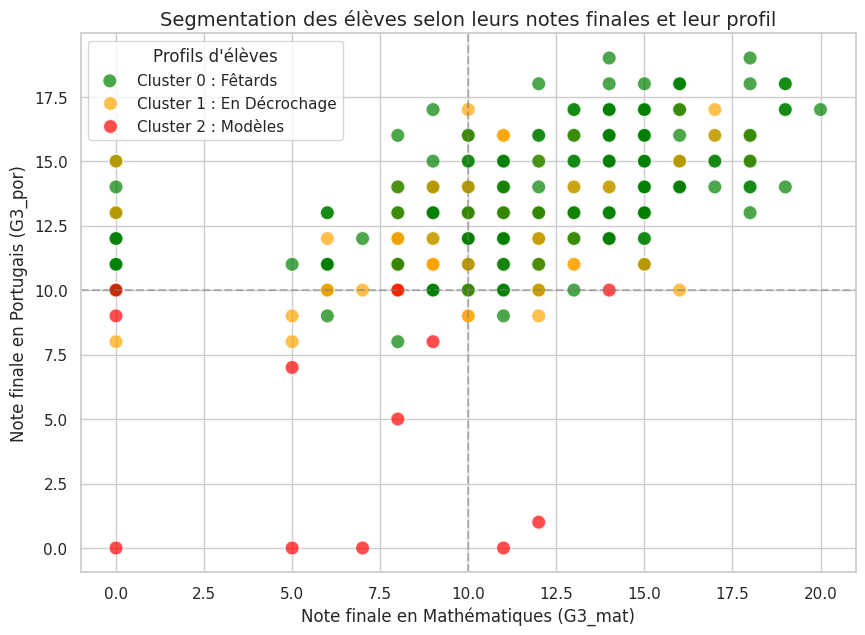

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Création d'un graphique à bulles (Scatter plot) coloré par Cluster
sns.scatterplot(
    data=df_final,
    x="G3_mat",
    y="G3_por",
    hue="Cluster",
    palette=["orange", "red", "green"], # 0: Orange (Fêtards), 1: Rouge (Décrochage), 2: Vert (Modèles)
    alpha=0.7,
    s=100
)

plt.title("Segmentation des élèves selon leurs notes finales et leur profil", fontsize=14)
plt.xlabel("Note finale en Mathématiques (G3_mat)", fontsize=12)
plt.ylabel("Note finale en Portugais (G3_por)", fontsize=12)
plt.legend(title="Profils d'élèves", labels=["Cluster 0 : Fêtards", "Cluster 1 : En Décrochage", "Cluster 2 : Modèles"])
plt.axhline(10, color='gray', linestyle='--', alpha=0.5) # Ligne de la moyenne (10/20)
plt.axvline(10, color='gray', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# Exporter le dataset final avec les clusters pour Tableau
df_final.to_csv("dataset_final_tableau.csv", index=False)